# Learning From Data

## Workshop introduction: why move to richer hypothesis spaces?

The previous workshop decomposed supervised learning into three ingredients:

$$
\mathcal{D} + \mathcal{H} + \mathcal{O} \rightarrow s.
$$

Here $\mathcal{D}$ is the observed evidence, $\mathcal{H}$ is the set of functions the learner is allowed to choose from, $\mathcal{O}$ is the optimisation and selection procedure, and $s$ is the selected solution.

This workshop keeps that frame but changes the emphasis. We now ask what happens when simple, fixed hypothesis spaces are not expressive enough, and how compositional hypothesis spaces can build richer representations from simpler parts.

In [ ]:
# Environment setup. The notebook is designed to run locally and in Colab.
import os
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "nextgen2026-matplotlib")
)

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

if "google.colab" in sys.modules:
    repo_dir = Path("/content/nextgen2026-mlai-workshops")
    if not repo_dir.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "workshop1",
                "https://github.com/nextgenerationgraduatesprogram/nextgen2026-mlai-workshops.git",
                str(repo_dir),
            ],
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_dir)], check=True)
    sys.path.insert(0, str(repo_dir / "src"))
else:
    for possible_root in (Path.cwd(), Path.cwd().parent):
        possible_src = possible_root / "src"
        if (possible_src / "nextgen2026_mlai_workshops").exists():
            sys.path.insert(0, str(possible_src))
            break

<br>

## The Running Example: Tilt and Power

Throughout the workshop, we will return to one deliberately simple regression problem. A learner observes a finite dataset of measured tilt-power pairs:

$$
X=\text{observed tilt angle},\qquad Y=\text{observed power output},\qquad \mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

The immediate task is to learn a prediction rule

$$
h:\mathcal{X}\to\mathcal{Y},\qquad h(x)\approx Y,
$$

so that, given an observed tilt angle, the model predicts observed power output.

This example is simple enough to plot, but it contains the problems that make learning from data subtle. The learner may not observe the true physical tilt $\Theta$, hidden context $C$ may affect output, the dataset may have gaps or sparse regions, and the deployment setting may not match the data collection setting.

We will use this same example to ask four connected questions:

| Notebook | Question about the tilt-power example |
|---|---|
| `01_data_space.ipynb` | What does the observed tilt-power dataset support? |
| `02_hypothesis_space.ipynb` | What functions become available when the hypothesis space becomes richer? |
| `03_optimization_space.ipynb` | How does training select one solution from the available functions? |
| `04_solution_space.ipynb` | What claim is the selected MLP actually supported for? |

The example is not about solar panels in particular. It is a controlled setting for seeing where a model's behaviour comes from: the data collected, the functions allowed, the optimisation procedure, or the evaluation claim.


### A First Look at the Observed Dataset

The plot below shows the learner's view of one finite tilt-power dataset. Each point is one observed pair $(x_i,y_i)$. The hidden physical tilt, context, noise process, and sampling rule are not visible to the learner from this plot alone.

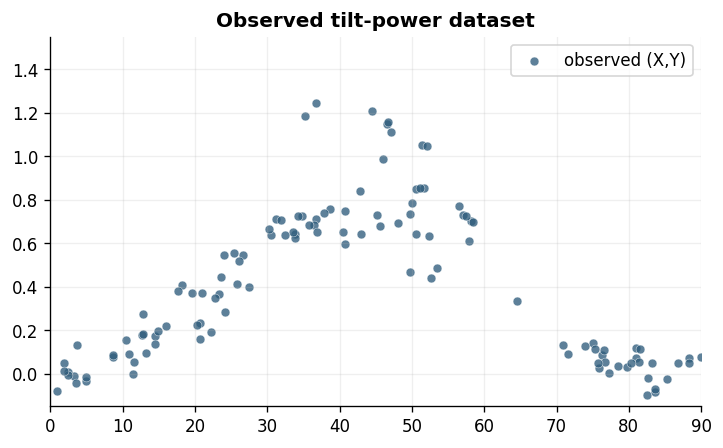

In [3]:
import matplotlib.pyplot as plt

from nextgen2026_mlai_workshops.data_space import (
    configure_matplotlib,
    plot_observed,
    sample_tilt_power,
    style_xy_axis,
)

configure_matplotlib()

data = sample_tilt_power(
    n=120,
    seed=7,
    scenario="hidden_context",
    sampling="sparse_feature",
    context_mode="increasing",
    x_noise=2.0,
    y_noise=0.06,
    context_strength=0.25,
)

fig, ax = plt.subplots(figsize=(7, 4))
plot_observed(ax, data, reveal_context=False)
style_xy_axis(ax)
ax.set_title("Observed tilt-power dataset")
ax.legend(loc="upper right")
plt.show()


<br>

## Learning Objectives

By the end of this opening notebook, you should be able to:

1. recall the roles of data space, hypothesis space, optimisation space, and generalisation from Workshop 1;
2. explain why finite data alone rarely determines one defensible prediction rule;
3. describe why simple hypothesis spaces can underfit even when optimisation is successful;
4. explain the motivation for moving from fixed feature maps to learned representations;
5. identify the main question for this workshop: what changes when $\mathcal{H}$ becomes richer?

The rest of the workshop studies this question through data support, learned features, optimisation behaviour, and investigation practice.

<br>

## 1. A Brief Refresher on Workshop 1

A supervised dataset is a finite set of observed input-output pairs:

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n}.
$$

A hypothesis space is a set of candidate prediction rules:

$$
\mathcal{H}=\{h_{\theta}:\theta\in\Theta\}.
$$

An optimisation or selection procedure chooses one candidate using the available evidence:

$$
\widehat{\theta}
\in
\operatorname*{arg\,min}_{\theta\in\Theta}
\widehat{R}_{\mathcal{D}}(h_\theta),
\qquad
s=h_{\widehat{\theta}}.
$$

The selected solution is therefore not just a property of the data. It is a product of the data collected, the functions made available, and the rule used to choose among them.

Keep this diagnostic question visible throughout the workshop:

> When a model behaves surprisingly, did the behaviour come from $\mathcal{D}$, $\mathcal{H}$, $\mathcal{O}$, or the evaluation setting?

<br>

## 2. When Do Simple Hypothesis Spaces Struggle

In Workshop 1, simple families such as linear models and polynomial curves were useful because every ingredient was visible. We could see the data points, the feature columns, the fitted curve, the loss, and the failure modes.

$$
\mathcal{H}_{d}
=
\left\{x\mapsto \sum_{k=0}^{d}\theta_kx^k\right\}
$$

However:

1. A restricted $\mathcal{H}$ can make optimisation easier but may be too small to represent the pattern we need.
2. A more expressive $\mathcal{H}$ can reduce approximation error, but the resulting search problem may be harder to optimise and easier to overfit where data support is weak.
3. Hand-designed features can help, but they place much of the modelling burden on the designer and still leave optimisation constrained by the chosen representation.

The limitation, then, is not only that simple hypothesis spaces are restrictive. It is that complex problems require a representation rich enough to express useful structure while still being trainable from finite data.

The next step is to ask whether the learner can build useful features rather than only receive them.

<br>

## 3. A Flexible Approach to Hypothesis Space Design

One response is to stop treating feature design as a single hand-coded step. Instead of choosing one fixed feature map, we can define $\mathcal{H}$ from simpler building blocks that can be composed:

$$
h(x)=(g_m\circ g_{m-1}\circ\cdots\circ g_1)(x),\qquad g_i\in\mathcal{G}_i.
$$

Each block may be simple, but the composition can express richer structure than any one block alone. Early blocks can reorganise the input into useful intermediate quantities; later blocks can combine those quantities into more abstract, task-relevant structure.

The design question therefore changes from "which features should we hand-code?" to "which building blocks and compositions should the learner be allowed to use?"

So the hypothesis-space question becomes richer:

$$
\mathcal{H}_{\mathrm{comp}}
=
\{x\mapsto (g_m\circ\cdots\circ g_1)(x):g_i\in\mathcal{G}_i\}.
$$

This does not remove the Workshop 1 questions. It makes them more important. A compositional $\mathcal{H}$ changes what can be represented, how optimisation behaves, and what kind of evidence is needed to trust the selected solution.

<br>

## 4. How Does A Richer Hypothesis Space Interact With The Learning Problem

A richer hypothesis space is not a shortcut around learning from finite evidence.

If $\mathcal{D}$ has poor coverage, missing variables, label noise, or deployment mismatch, a richer model may confidently learn the wrong pattern. If $\mathcal{O}$ uses a poorly matched loss, unstable learning rate, weak regularisation, or unlucky initialisation, training may select a solution for the wrong reason. If evaluation reuses data that influenced modelling decisions, reported performance may be optimistic.

The goal is to understand how richer hypothesis spaces $\mathcal{H}$ interact with data support, optimisation, and generalisation.

A useful working question is:

> What extra behaviours become possible when $\mathcal{H}$ is richer, and what extra evidence or discipline is needed before trusting those behaviours?

<br>

## 5. Workshop Roadmap

The workshop now revisits the same learning frame with richer hypothesis spaces in view.

| Notebook | Focus | Role in the workshop |
|---|---|---|
| `01_data_space.ipynb` | Data support | Revisit what finite observations can support when the model class can represent more complex relationships. |
| `02_hypothesis_space.ipynb` | Learned representations | Move from fixed feature maps to neurons, width, depth, architecture, and inductive bias. |
| `03_optimization_space.ipynb` | Training dynamics | Study how losses, landscapes, gradients, minibatches, regularisation, non-convexity, and early stopping select one solution. |
| `04_solution_space.ipynb` | Solution-space diagnosis | Use the $\mathcal{D}+\mathcal{H}+\mathcal{O}\rightarrow s$ frame to diagnose model behaviour and make defensible modelling arguments. |

The through-line is unchanged:

$$
\text{learning from data means selecting a function from finite evidence under modelling assumptions.}
$$

What changes in this workshop is the richness of the functions made available.